# Random Forest Comparison: v1 vs v2 vs v3

This notebook trains a Random Forest classifier with GridSearchCV across three prepared datasets:
- **v1**: `X_*_v1.csv` (Aimon, 94 features)
- **v2**: `X_*_v2.csv` (Aimon, 11 features)
- **v3**: `X_*.csv` (Airam, 106 features)

## Selection rule
- **Primary model selection**: highest **Validation PR-AUC** (threshold-free, stable for imbalance)
- **Threshold tuning per version**: maximize **Validation G-Mean** on ROC thresholds
- **Paper-comparable metric**: report **G-Mean** on both validation and test sets

In [ ]:
import os
os.environ['PYTHONWARNINGS'] = 'ignore'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
pd.set_option('display.max_columns', 200)

In [2]:
# Version configuration
VERSIONS = {
    'v1': {
        'base_dir': Path('../data/aimon-data'),
        'x_train': 'X_train_v1.csv',
        'x_val': 'X_val_v1.csv',
        'x_test': 'X_test_v1.csv',
        'y_train': 'y_train.csv',
        'y_val': 'y_val.csv',
        'y_test': 'y_test.csv',
    },
    'v2': {
        'base_dir': Path('../data/aimon-data'),
        'x_train': 'X_train_v2.csv',
        'x_val': 'X_val_v2.csv',
        'x_test': 'X_test_v2.csv',
        'y_train': 'y_train.csv',
        'y_val': 'y_val.csv',
        'y_test': 'y_test.csv',
    },
    'v3': {
        'base_dir': Path('../data/airam-data'),
        'x_train': 'X_train.csv',
        'x_val': 'X_val.csv',
        'x_test': 'X_test.csv',
        'y_train': 'y_train.csv',
        'y_val': 'y_val.csv',
        'y_test': 'y_test.csv',
    },
}

## 1. Helper Functions

In [3]:
def gmean_from_labels(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    rec = tp / (tp + fn + 1e-12)
    spec = tn / (tn + fp + 1e-12)
    return np.sqrt(rec * spec), rec, spec, cm


def load_version_data(cfg):
    base = cfg['base_dir']
    X_train = pd.read_csv(base / cfg['x_train'])
    X_val   = pd.read_csv(base / cfg['x_val'])
    X_test  = pd.read_csv(base / cfg['x_test'])
    y_train = pd.read_csv(base / cfg['y_train']).squeeze()
    y_val   = pd.read_csv(base / cfg['y_val']).squeeze()
    y_test  = pd.read_csv(base / cfg['y_test']).squeeze()
    return X_train, X_val, X_test, y_train, y_val, y_test

## 2. Hyperparameter Tuning & Evaluation per Version

In [4]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

print('Hyperparameter Grid:')
for k, v in param_grid.items():
    print(f'  {k}: {v}')
print(f'  Total combinations: {np.prod([len(v) for v in param_grid.values()])}')

Hyperparameter Grid:
  n_estimators: [100, 200, 300]
  max_depth: [5, 10, 15, None]
  min_samples_split: [2, 5, 10]
  min_samples_leaf: [1, 2, 4]
  Total combinations: 108


In [5]:
def evaluate_rf_version(version_name, cfg):
    X_train, X_val, X_test, y_train, y_val, y_test = load_version_data(cfg)
    print(f'\n{"=" * 70}')
    print(f'Training {version_name} — {X_train.shape[1]} features, {X_train.shape[0]} samples')
    print(f'{"=" * 70}')

    # No scaling needed for Random Forest (tree-based)
    rf_base = RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    grid = GridSearchCV(
        rf_base,
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=1,
    )
    grid.fit(X_train, y_train)

    print(f'Best params: {grid.best_params_}')
    print(f'Best CV ROC-AUC: {grid.best_score_:.6f}')

    model = grid.best_estimator_

    # --- Validation ---
    y_val_prob = model.predict_proba(X_val)[:, 1]
    val_roc_auc = roc_auc_score(y_val, y_val_prob)
    val_pr_auc  = average_precision_score(y_val, y_val_prob)

    # G-Mean threshold tuning on validation
    fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)
    gmean_vals = np.sqrt(tpr * (1 - fpr))
    best_idx = int(np.argmax(gmean_vals))
    best_th  = thresholds[best_idx]

    y_val_pred = (y_val_prob >= best_th).astype(int)
    val_gmean, val_recall, val_specificity, val_cm = gmean_from_labels(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
    val_precision = precision_score(y_val, y_val_pred, zero_division=0)

    # --- Test (using validation threshold) ---
    y_test_prob = model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_prob >= best_th).astype(int)

    test_roc_auc = roc_auc_score(y_test, y_test_prob)
    test_pr_auc  = average_precision_score(y_test, y_test_prob)
    test_gmean, test_recall, test_specificity, test_cm = gmean_from_labels(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
    test_precision = precision_score(y_test, y_test_pred, zero_division=0)

    result = {
        'version': version_name,
        'n_features': X_train.shape[1],
        'best_params': str(grid.best_params_),
        'cv_roc_auc': grid.best_score_,
        'val_pr_auc': val_pr_auc,
        'val_roc_auc': val_roc_auc,
        'val_gmean': val_gmean,
        'val_f1': val_f1,
        'val_recall': val_recall,
        'val_precision': val_precision,
        'val_specificity': val_specificity,
        'best_threshold_gmean': best_th,
        'test_pr_auc': test_pr_auc,
        'test_roc_auc': test_roc_auc,
        'test_gmean': test_gmean,
        'test_f1': test_f1,
        'test_recall': test_recall,
        'test_precision': test_precision,
        'test_specificity': test_specificity,
    }

    artifacts = {
        'model': model,
        'val_curve': (fpr, tpr, thresholds, gmean_vals),
        'val_cm': val_cm,
        'test_cm': test_cm,
        'y_val': y_val,
        'y_val_prob': y_val_prob,
        'y_test': y_test,
        'y_test_prob': y_test_prob,
        'y_test_pred': y_test_pred,
        'feature_names': list(X_train.columns),
    }

    return result, artifacts

In [6]:
all_results = []
all_artifacts = {}

for vname, cfg in VERSIONS.items():
    res, art = evaluate_rf_version(vname, cfg)
    all_results.append(res)
    all_artifacts[vname] = art

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('val_pr_auc', ascending=False).reset_index(drop=True)

best_version = results_df.loc[0, 'version']
print(f'\nBest version by Validation PR-AUC: {best_version}')


Training v1 — 94 features, 4773 samples
Fitting 5 folds for each of 108 candidates, totalling 540 fits


/opt/anaconda3/envs/dslearn/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/dslearn/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/dslearn/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/dslearn/lib/python3.14/site-packages/s

Best params: {'max_depth': 15, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Best CV ROC-AUC: 0.929168

Training v2 — 11 features, 4773 samples
Fitting 5 folds for each of 108 candidates, totalling 540 fits


/opt/anaconda3/envs/dslearn/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/dslearn/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/dslearn/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/dslearn/lib/python3.14/site-packages/s

Best params: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best CV ROC-AUC: 0.823668

Training v3 — 106 features, 4364 samples
Fitting 5 folds for each of 108 candidates, totalling 540 fits


/opt/anaconda3/envs/dslearn/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/dslearn/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/dslearn/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/anaconda3/envs/dslearn/lib/python3.14/site-packages/s

Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best CV ROC-AUC: 0.944208

Best version by Validation PR-AUC: v3


## 3. Results Comparison

In [7]:
print('=== Random Forest Comparison (v1/v2/v3) ===')
print(f'Selection rule: highest Validation PR-AUC')
print(f'Best version: {best_version}')
print()

display_cols = [
    'version', 'n_features',
    'val_pr_auc', 'val_gmean', 'val_f1',
    'test_pr_auc', 'test_gmean', 'test_f1', 'test_recall',
    'best_threshold_gmean',
]

print(results_df[display_cols].to_string(index=False))

=== Random Forest Comparison (v1/v2/v3) ===
Selection rule: highest Validation PR-AUC
Best version: v3

version  n_features  val_pr_auc  val_gmean   val_f1  test_pr_auc  test_gmean  test_f1  test_recall  best_threshold_gmean
     v3         106    0.401078   0.895123 0.267717     0.494211    0.847964 0.250825     0.863636              0.029783
     v1          94    0.392637   0.893811 0.327869     0.495332    0.829218 0.281081     0.787879              0.097663
     v2          11    0.100014   0.749043 0.135747     0.110102    0.748859 0.133909     0.939394              0.261887


In [8]:
# Paper-comparable view (G-Mean emphasized)
paper_compare = results_df[[
    'version', 'n_features',
    'val_gmean', 'test_gmean',
    'val_pr_auc', 'test_pr_auc',
    'best_threshold_gmean',
]].copy()

paper_compare

,version,n_features,val_gmean,test_gmean,val_pr_auc,test_pr_auc,best_threshold_gmean
0,v3,106,0.895123,0.847964,0.401078,0.494211,0.029783
1,v1,94,0.893811,0.829218,0.392637,0.495332,0.097663
2,v2,11,0.749043,0.748859,0.100014,0.110102,0.261887


In [9]:
# Full results
results_df

,version,n_features,best_params,cv_roc_auc,val_pr_auc,val_roc_auc,val_gmean,val_f1,val_recall,val_precision,val_specificity,best_threshold_gmean,test_pr_auc,test_roc_auc,test_gmean,test_f1,test_recall,test_precision,test_specificity
0,v3,106,"{'max_depth': None, 'min_samples_leaf': 2, 'mi...",0.944208,0.401078,0.944048,0.895123,0.267717,0.971429,0.155251,0.824811,0.029783,0.494211,0.945265,0.847964,0.250825,0.863636,0.146718,0.832576
1,v1,94,"{'max_depth': 15, 'min_samples_leaf': 4, 'min_...",0.929168,0.392637,0.944322,0.893811,0.327869,0.909091,0.200000,0.878788,0.097663,0.495332,0.941781,0.829218,0.281081,0.787879,0.171053,0.872727
2,v2,11,"{'max_depth': 5, 'min_samples_leaf': 4, 'min_s...",0.823668,0.100014,0.803459,0.749043,0.135747,0.909091,0.073350,0.617172,0.261887,0.110102,0.822498,0.748859,0.133909,0.939394,0.072093,0.596970


## 4. Visualizations

### 4.1 Validation G-Mean vs Threshold

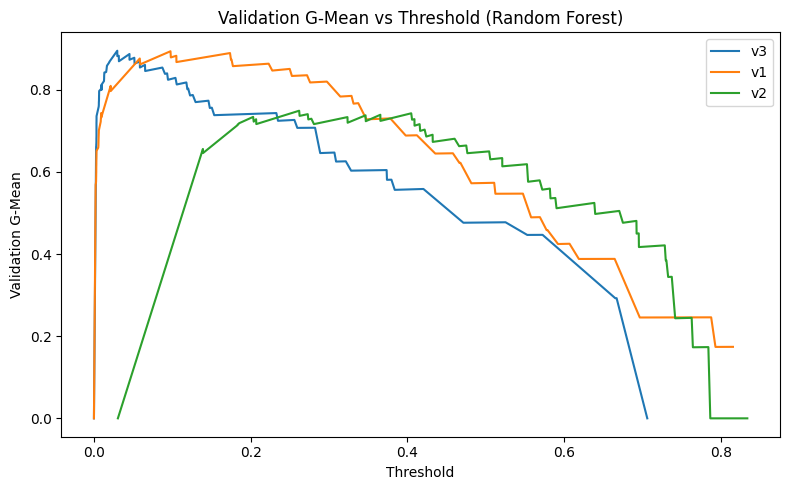

In [10]:
plt.figure(figsize=(8, 5))

for vname in results_df['version']:
    fpr, tpr, thresholds, gvals = all_artifacts[vname]['val_curve']
    plt.plot(thresholds, gvals, label=vname)

plt.xlabel('Threshold')
plt.ylabel('Validation G-Mean')
plt.title('Validation G-Mean vs Threshold (Random Forest)')
plt.legend()
plt.tight_layout()
plt.show()

### 4.2 ROC Curves

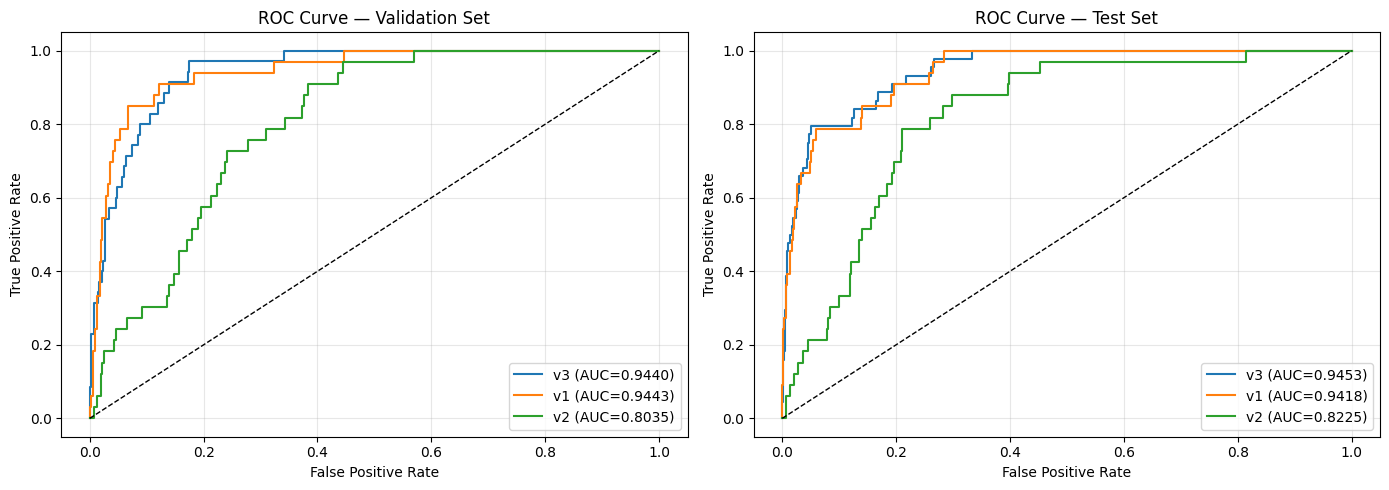

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for vname in results_df['version']:
    art = all_artifacts[vname]
    fpr_v, tpr_v, _, _ = art['val_curve']
    val_auc = roc_auc_score(art['y_val'], art['y_val_prob'])
    axes[0].plot(fpr_v, tpr_v, label=f'{vname} (AUC={val_auc:.4f})')

    fpr_t, tpr_t, _ = roc_curve(art['y_test'], art['y_test_prob'])
    test_auc = roc_auc_score(art['y_test'], art['y_test_prob'])
    axes[1].plot(fpr_t, tpr_t, label=f'{vname} (AUC={test_auc:.4f})')

for ax, title in zip(axes, ['Validation', 'Test']):
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {title} Set')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.3 Confusion Matrix — Best Version (Test Set)

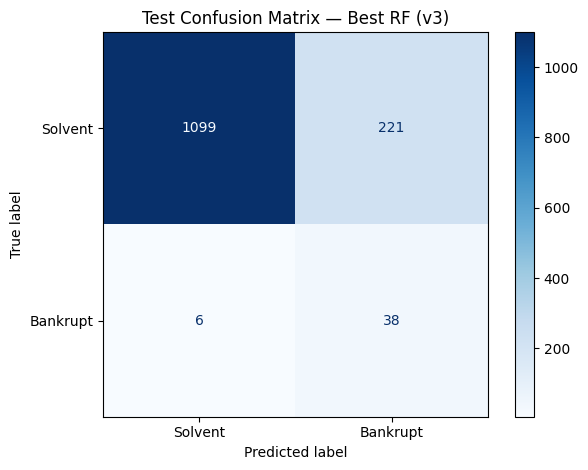

In [12]:
best_art = all_artifacts[best_version]
cm = best_art['test_cm']

disp = ConfusionMatrixDisplay(cm, display_labels=['Solvent', 'Bankrupt'])
disp.plot(values_format='d', cmap='Blues')
plt.title(f'Test Confusion Matrix — Best RF ({best_version})')
plt.tight_layout()
plt.show()

### 4.4 Feature Importance — Best Version (Top 20)

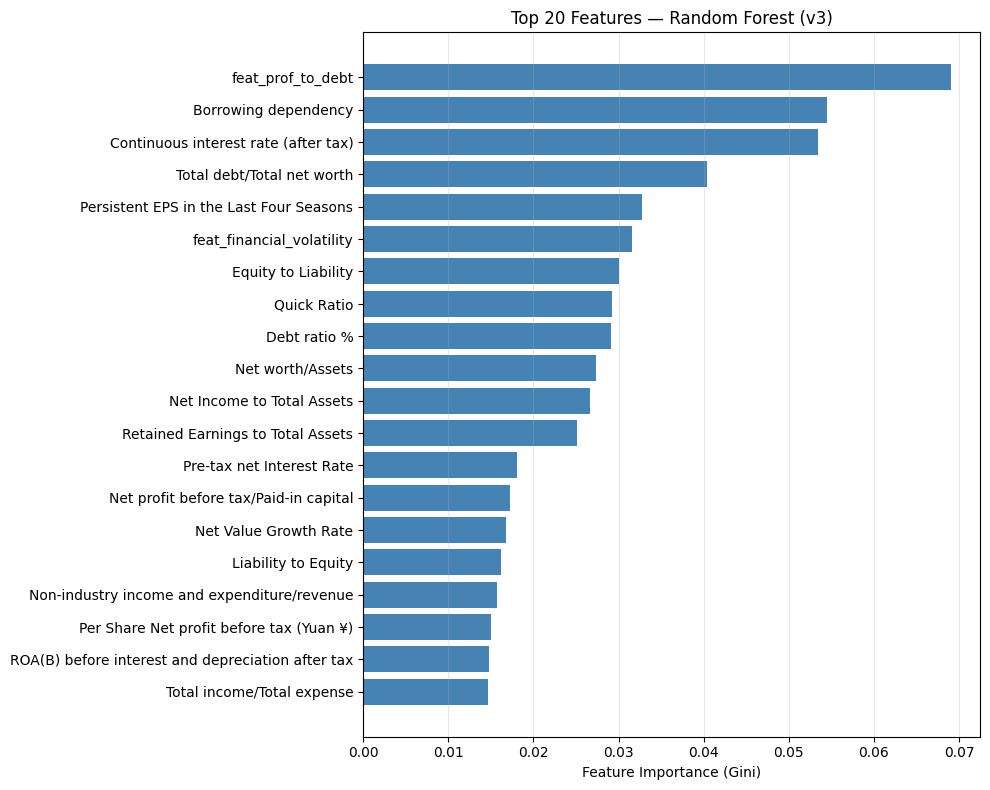


Top 20 Features:
                                          feature  importance
                                feat_prof_to_debt    0.069002
                             Borrowing dependency    0.054450
             Continuous interest rate (after tax)    0.053429
                       Total debt/Total net worth    0.040400
          Persistent EPS in the Last Four Seasons    0.032737
                        feat_financial_volatility    0.031605
                              Equity to Liability    0.030054
                                      Quick Ratio    0.029253
                                     Debt ratio %    0.029059
                                 Net worth/Assets    0.027369
                       Net Income to Total Assets    0.026621
                Retained Earnings to Total Assets    0.025122
                        Pre-tax net Interest Rate    0.018059
            Net profit before tax/Paid-in capital    0.017242
                            Net Value Growth Rate   

In [13]:
best_model = best_art['model']
feat_names = best_art['feature_names']

fi_df = pd.DataFrame({
    'feature': feat_names,
    'importance': best_model.feature_importances_,
}).sort_values('importance', ascending=False)

top_n = min(20, len(fi_df))
top = fi_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(top_n), top['importance'].values, color='steelblue')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top['feature'].values)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title(f'Top {top_n} Features — Random Forest ({best_version})')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f'\nTop {top_n} Features:')
print(top.to_string(index=False))

## 5. Save Results

In [14]:
results_df.to_csv('../data/processed/random_forest_results.csv', index=False)
print('Results saved to data/processed/random_forest_results.csv')

Results saved to data/processed/random_forest_results.csv


## Notes
- Random Forest does not require feature scaling (tree-based splits are scale-invariant).
- `class_weight='balanced'` handles the ~3.2% positive class imbalance.
- Best model selected by **Validation PR-AUC**, then evaluated on test using the **validation-chosen G-Mean threshold**.
- No test-set threshold tuning is performed.